# DINO

## Documentación

https://huggingface.co/docs/transformers/model_doc/dinov2

<div style="background:#FFFFE0;padding:20px;color:#000000;margin-top:10px;">

<p> 
DINOv2 es una herramienta desarrollada por Meta AI. Es un modelo de aprendizaje, el cual se encarga de extracción de características de imágenes. Este aprende representaciones visuales, lo que le permite poder capturar estructuras de imágenes y poder entender las similitudes entre ellas.

Sus usos:
</p>

<ul>
    <li>
      <p> Similitud de imágenes, donde puede comparar las similitudes entre imágenes</p>
    </li>
    <li>
        <p>Clasificación de imágenes donde permite identificar objetos dentro de una imagen</p>
    </li>
    <li>
       <p> Segmentación de semántica, donde puede agrupar las áreas similares dentro de una imagen </p>
    </li>
    <li>
       <p> Recuperación de imágenes similares, donde ayuda a encontrar esas imágenes dentro de un grupo de imágenes </p>
    </li>
    <ul>
</div>

## Importar librerías

In [1]:
import os
import torch
import numpy as np
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoImageProcessor, AutoModel

/usr/local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_path = os.environ['OUTPUT_DIR']

In [3]:
image_files = [f for f in os.listdir(dataset_path) if f.endswith(('.jpg', '.png', '.jpeg', '.webp'))]

<div style="background:#FFFFE0;padding:20px;color:#000000;margin-top:10px;">

  <p>
    (Teoría)
    DINOv2 cuenta con varios algoritmos y componentes dentro de su propio flujo de trabajo de procesamiento y entrenamiento.

Entre ellos están:
  </p>

  <p><strong>AutoImageProcessor:</strong> es parte de la biblioteca transformers y se encarga de preprocesar las imágenes automáticamente antes de ser pasadas al modelo. Es muy útil para asegurarse de que las imágenes estén en el formato adecuado para el procesamiento sin necesidad de preocuparse por los detalles del mismo.</p>
   
  <p><strong>AutoModel:</strong> es parte de la biblioteca transformers. Se encarga de cargar el modelo preentrenado y aplicarlo a una entrada de imágenes para obtener los resultados como características de imagen o predicciones.</p>
   
  <p><strong>Torchvision:</strong> es una biblioteca de visión por computadora, utilizada en PyTorch. Esta se encarga de preprocesar las imágenes, preentrenar modelos y transformar las imágenes.</p>
  <p>Esta puede ser una alternativa a AutoImageProcessor ya que puede usar las transformaciones de la biblioteca torchvision para preprocesar las imágenes. Asimismo, también puede ser una alternativa para AutoModel, porque puede usar los modelos preentrenados de torchvision y extraer las características de las imágenes directamente.</p>
  
  <a href="https://huggingface.co/docs/transformers/main/en/image_processors?image-processor-classes=AutoImageProcessor">Documentación AutoImageProcessor</a>
  <a href="https://pytorch.org/vision/stable/index.html">Documentación Torchvision</a>
  <a href=:https://huggingface.co/transformers/v3.0.2/model_doc/auto.html>Documentación AutoModel</a>
  
</div>


In [4]:
# DINO model
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
model = AutoModel.from_pretrained('facebook/dinov2-base')

In [5]:
# Extaer features
def extract_features(image, model, processor):
     # Abrir y preprocesar imagen
    image = Image.open(image).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    
    # Extrae features
    with torch.no_grad():
        outputs = model(**inputs)
        features = outputs.last_hidden_state.mean(dim=1).detach().cpu().numpy()
    
    return features


In [6]:
features_list = []
for image_file in image_files:
    image_path = os.path.join(dataset_path, image_file)  
    print(f"Procesando: {image_path}") 
    try:
        features = extract_features(image_path, model, processor)
        features_list.append(features)
    except FileNotFoundError as e:
        print(f"Error: {e}")

print(f"Total de imágenes procesadas: {len(features_list)}")

Procesando: /root/work/_Results/test_01-Scene-001-01.webp
Procesando: /root/work/_Results/test_01-Scene-001-02.webp
Procesando: /root/work/_Results/test_01-Scene-001-03.webp
Procesando: /root/work/_Results/test_01-Scene-002-01.webp
Procesando: /root/work/_Results/test_01-Scene-002-02.webp
Procesando: /root/work/_Results/test_01-Scene-002-03.webp
Procesando: /root/work/_Results/test_01-Scene-003-01.webp
Procesando: /root/work/_Results/test_01-Scene-003-02.webp
Procesando: /root/work/_Results/test_01-Scene-003-03.webp
Procesando: /root/work/_Results/test_01-Scene-004-01.webp
Procesando: /root/work/_Results/test_01-Scene-004-02.webp
Procesando: /root/work/_Results/test_01-Scene-004-03.webp
Procesando: /root/work/_Results/test_01-Scene-005-01.webp
Procesando: /root/work/_Results/test_01-Scene-005-02.webp
Procesando: /root/work/_Results/test_01-Scene-005-03.webp
Procesando: /root/work/_Results/test_01-Scene-006-01.webp
Procesando: /root/work/_Results/test_01-Scene-006-02.webp
Procesando: /r

<div style="background:#FFFFE0;padding:20px;color:#000000;margin-top:10px;">

<p> 
Para poder hacer uso de DINOv2, es necesario cargar el modelo correspondiente a ella, el cual ya ha sido preentrenado por Meta AI. Ese modelo lo que hace es que toma las imágenes procesadas y las convierte en vectores de caracteristicas que representan el contenido que se esta visualizando. También, es necesario cargar el preprocesamiento correspondiente el cual se encarga de preparar las imágenes para que el modelo pueda interpretarlas de la mejor manera.

Pasos:
</p>

<ul>
    <li>
      <p> Primero se carga la imagen donde la convierte en un formato RGB y preprocesa la imagen para convertirla en un tensor (números ya que los modelos trabajan con números) compatible con PyTorch, es decir, convierte la imagen a un formato en el que el modelo lo pueda leer,  </p>
    </li>
    <li>
        <p>Luego se extraen las características de la imagen</p>
    </li>
    <li>
       <p> Procesa el dataset que contiene las imagenes y extrae las caracteristicas y las va almacenando </p>
    </li>
    <li>
       <p> Se crea la matriz de similitud, la cual se encarga de encontrar las similitudes de las imágenes </p>
    </li>
    <li>
       <p> Por último se crea un heatmap de la similitud, donde podemos visualizar las similitudes que tienen las imágenes del dataset. Los colores de la imagen representan los valores de similitud; azul que es para baja similitud y rojo para alta similitud </p>
    </li>
    <ul>
</div>

In [7]:
# Esto es para crear una matrix de similitud
flattened_features = [feature.flatten() for feature in features_list]

# Calcular similitud
similarity_matrix = cosine_similarity(flattened_features)


<div style="background:#FFFFE0;padding:20px;color:#000000;margin-top:10px;">

<p> 
<strong>El Heatmap</strong>

Al analizar el heatmap, se observa como las áreas en rojo significan que algunas imágenes tienen características similares (visualizando el color rojo en el heatmap) como tambien algunas de ellas un colo azul la cual indicá que tiene bajas similitudes. Lo cual es cierto, si se revisa cada imagen y se mira como algunas de ellas (las mismas que dice el heatmap) tienen las mismas caracteristicas, se ven similares. También, como otras se ven diferentes y no tienen similitudes.
</p>
</div>

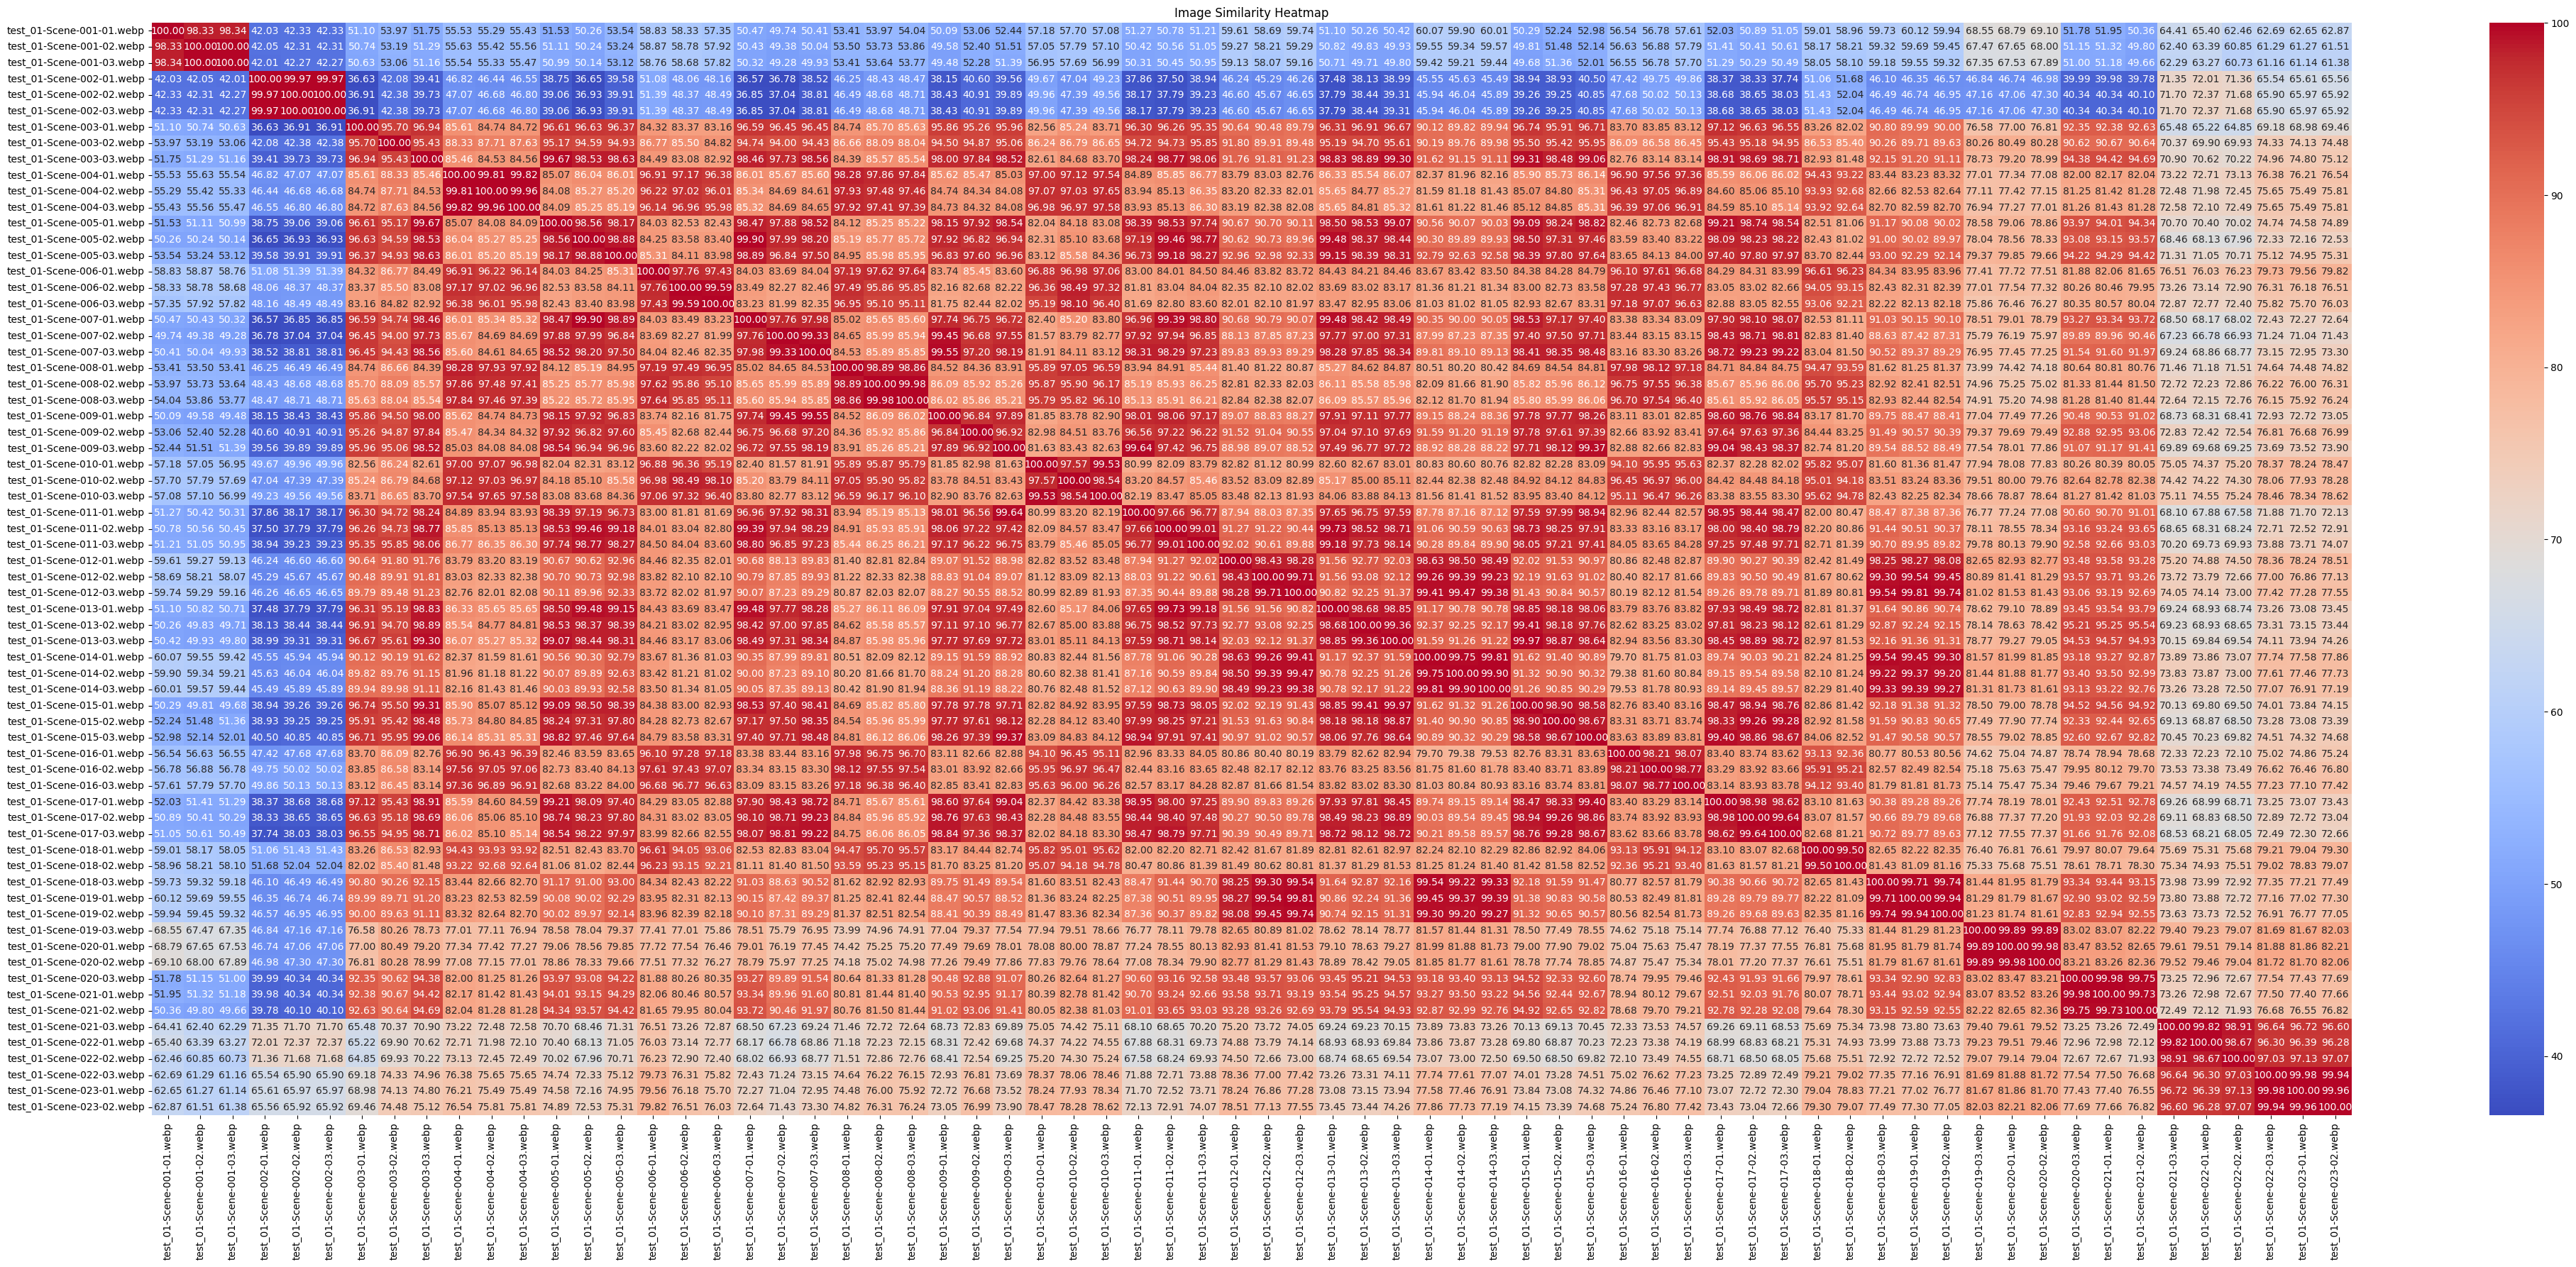

In [10]:
# Convertir similitudes a porcentaje
similarity_percentage = similarity_matrix * 100

plt.figure(figsize=(50, 20))
sns.heatmap(similarity_percentage, xticklabels=image_files, yticklabels=image_files, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Image Similarity Heatmap")
plt.show()


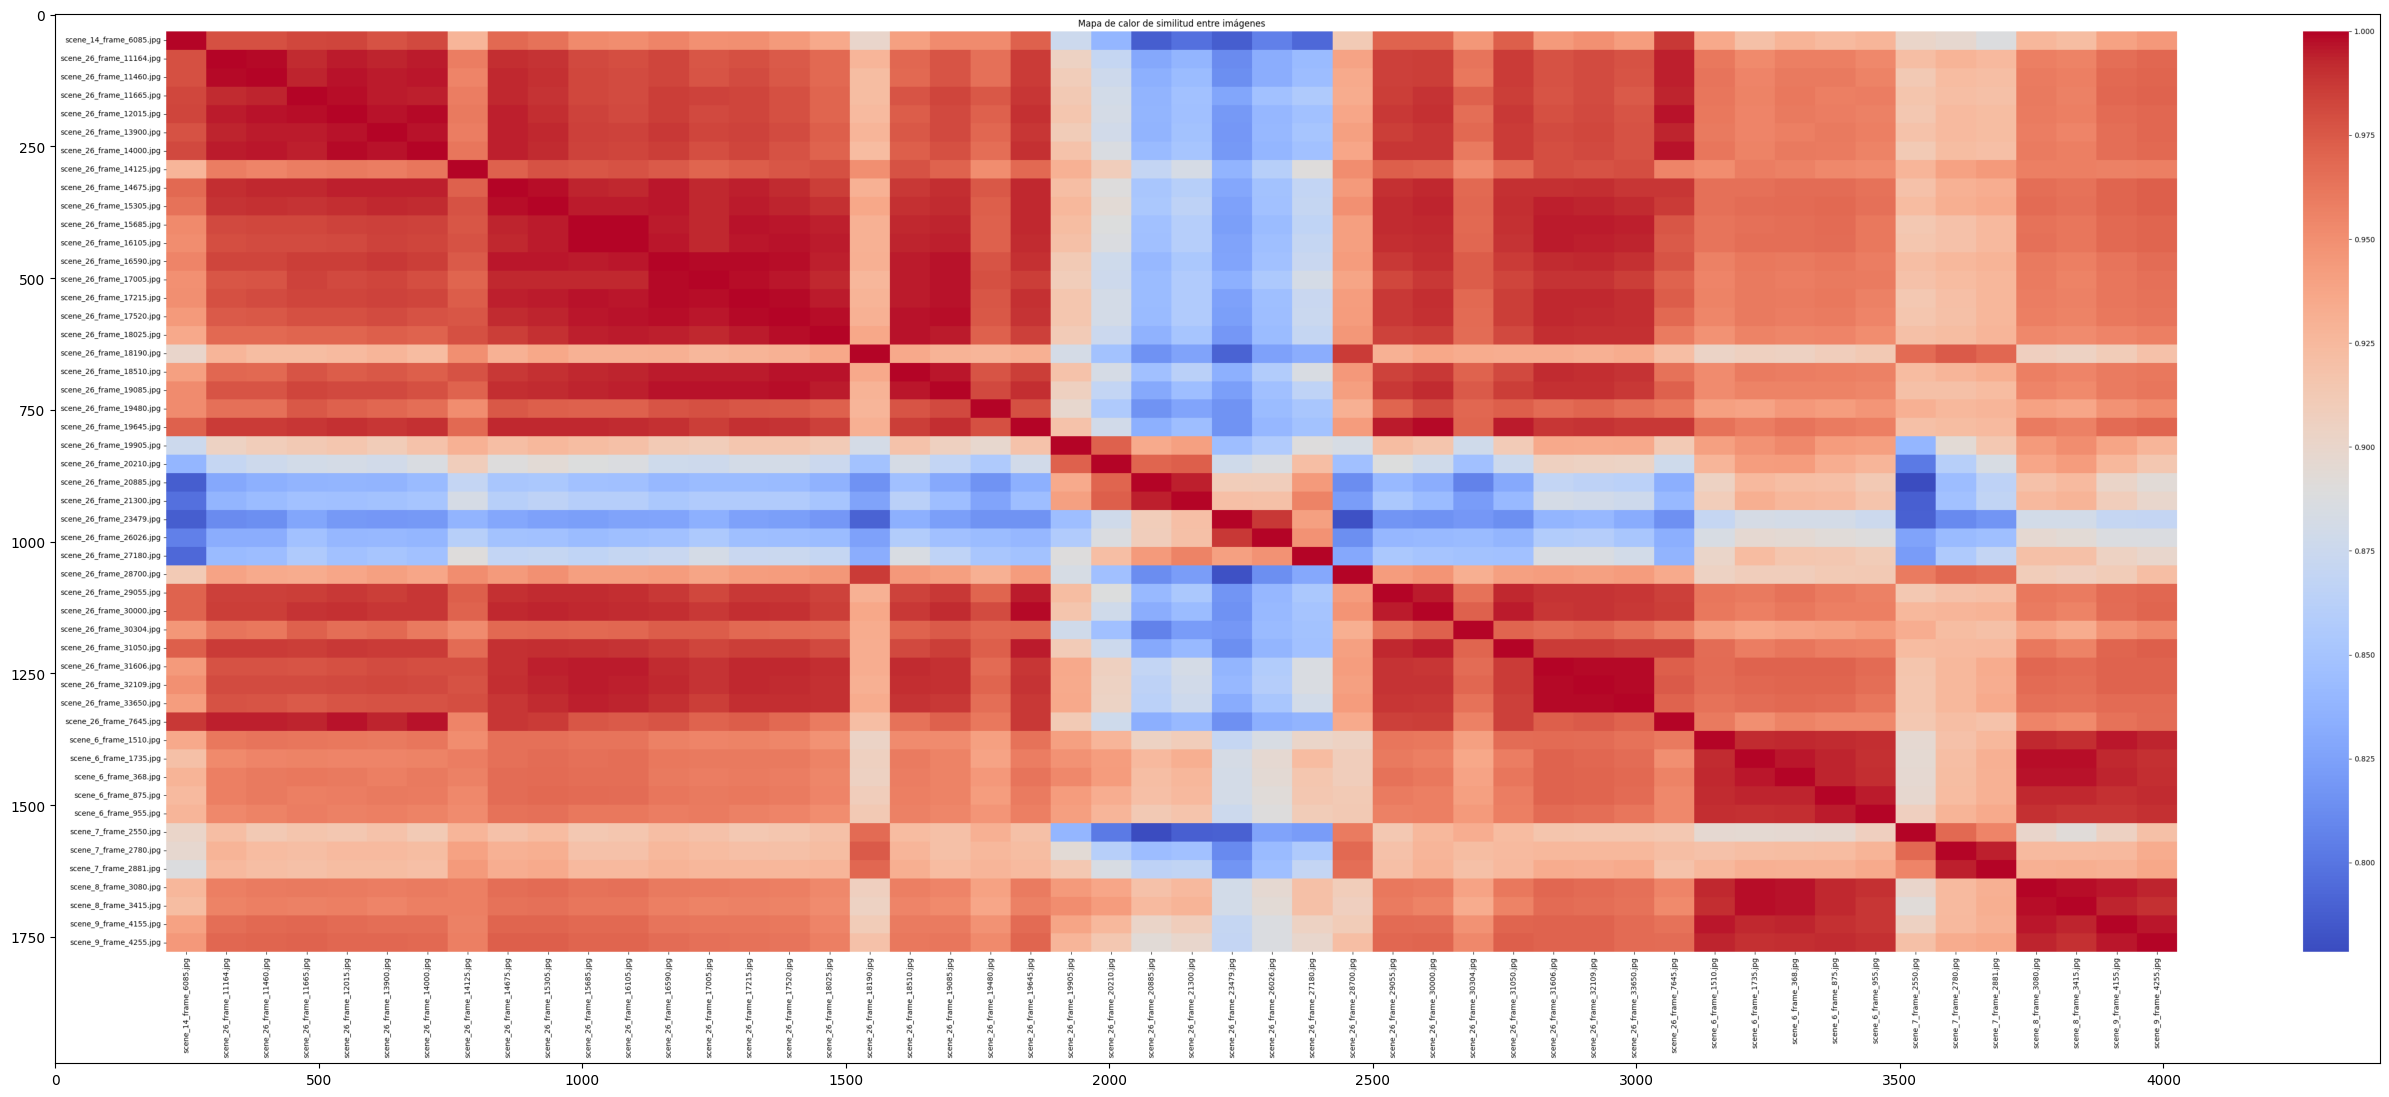

In [33]:
img_path = "/root/work/LogicMate_v1/notebooks/__dinov2/torchvision_heatmap.png"

# Cargar y mostrar la imagen de heatmap de torchvision
img = mpimg.imread(img_path)
plt.figure(figsize=(30, 30)) 
plt.imshow(img)
plt.show()


<div style="background:#FFFFE0;padding:20px;color:#000000;margin-top:10px;">

<p> 
<strong>Resultados</strong>

El primer heatmap, generado con AutoImageProcessor y AutoModel, es útil para identificar grupos de imágenes similares, pero puede perder detalles intermedios si la similitud varía gradualmente. Este enfoque es ideal para detectar frames duplicados o muy similares en un video. El segundo heatmap, utilizando torchvision, muestra transiciones suaves que permiten observar las variaciones de similitud entre imágenes, lo cual es útil para analizar cambios progresivos, aunque puede ser más difícil de interpretar si se busca encontrar imágenes idénticas.

Es decir, si necesitamos identificar grupos claros de imágenes similares o detectar frames duplicados, podemos usar el primer heatmap ya que ofrecería una diferenciación clara entre las imagenes.

Sin embargo, si necesitamos observar como cambia la similitud de manera mas progresuva y detallada, o hacer un seguimiento en lo que seria los cambios en una secuencia de imagenes, podemos usar el segundo heatmap ya que mostraría una transición suave entre las imagenes.
</p>
</div>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=8e809eb8-650a-4468-a096-2a2830a4a1e1' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>